In [1]:
import glob
import corner
import sep

import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
import matplotlib.patches as patches
from matplotlib.patches import Rectangle
import pandas as pd
import numpy as np

from astropy.table import Table, hstack
from astropy.io import fits
from astropy.stats import sigma_clipped_stats
from astropy.convolution import convolve_fft, Gaussian2DKernel
from astropy.nddata import block_reduce

from photutils.detection import find_peaks

from bt_functions import grab_image, add_noise, plot_object, reduce


In [2]:
# ---------------------------
# -------- LOAD DATA --------
# ---------------------------

# redshift 7 is the default
# BlueTides data covers redshifts 7-12
redshift = 7

bluetides_path = '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_*/hlsp_bluetides_jwst_nircam_z{redshift}*_f*w_v1_sim-*.fits'
euclid_path = '/Volumes/SeagateBack/bluetides/euclid_*/hlsp_bluetides_euclid_nisp_z{redshift}*_sim-nopsf.fits'

img_path = '/Volumes/SeagateBack/bluetides/plots'
code_path = '/Volumes/SeagateBack/bluetides/code'

jwst_filenames = glob.glob(bluetides_path.format(redshift=redshift))       # finds all files in path with given format 
print("Number of JWST files:",len(jwst_filenames))       
euclid_filenames = glob.glob(euclid_path.format(redshift=redshift))
print("Number of Euclid files:",len(euclid_filenames))         

catalog = Table.read('/Volumes/SeagateBack/bluetides/code/og_catalog.ecsv')
catalog[:10]

Number of JWST files: 56
Number of Euclid files: 12


id,redshift,fileNumber,extensionNumber,stellarMass,BHmass,BHluminosity,haloMass,lum_FUV,flux_jwst.nircam.f090w,radius_jwst.nircam.f090w,flux_jwst.nircam.f115w,radius_jwst.nircam.f115w,flux_jwst.nircam.f150w,radius_jwst.nircam.f150w,flux_jwst.nircam.f200w,radius_jwst.nircam.f200w,flux_jwst.nircam.f277w,radius_jwst.nircam.f277w,flux_jwst.nircam.f356w,radius_jwst.nircam.f356w,flux_jwst.nircam.f410m,radius_jwst.nircam.f410m,flux_jwst.nircam.f444w,radius_jwst.nircam.f444w,flux_jwst.miri.f560w,radius_jwst.miri.f560w,flux_jwst.miri.f770w,radius_jwst.miri.f770w,flux_hst.wfc3.f105w,radius_hst.wfc3.f105w,flux_hst.wfc3.f125w,radius_hst.wfc3.f125w,flux_hst.wfc3.f140w,radius_hst.wfc3.f140w,flux_hst.wfc3.f160w,radius_hst.wfc3.f160w,flux_euclid.nisp.y,radius_euclid.nisp.y,flux_euclid.nisp.j,radius_euclid.nisp.j,flux_euclid.nisp.h,radius_euclid.nisp.h,flux_roman.wfi.f087,radius_roman.wfi.f087,flux_roman.wfi.f106,radius_roman.wfi.f106,flux_roman.wfi.f129,radius_roman.wfi.f129,flux_roman.wfi.f146,radius_roman.wfi.f146,flux_roman.wfi.f158,radius_roman.wfi.f158,flux_roman.wfi.f184,radius_roman.wfi.f184,flux_subaru.hsc.z,radius_subaru.hsc.z,flux_subaru.hsc.y,radius_subaru.hsc.y,flux_vista.vircam.z,radius_vista.vircam.z,flux_vista.vircam.y,radius_vista.vircam.y,flux_vista.vircam.j,radius_vista.vircam.j,flux_vista.vircam.h,radius_vista.vircam.h,flux_vista.vircam.ks,radius_vista.vircam.ks,flux_spitzer.irac.ch1,flux_spitzer.irac.ch2
int64,float64,int64,int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
1,7.0,1,1,62058380000.0,374432960.0,9.854875355041004e+46,1292328500000.0,2.785938274534815e+29,23.11590576171875,1.2503641843795776,169.21633911132812,1.1419026851654053,186.37940979003906,1.058977723121643,195.3888702392578,0.99473637342453,261.0684814453125,0.893967866897583,470.4862060546875,0.8837507963180542,635.4224243164062,0.8629537224769592,543.959228515625,0.8785976767539978,623.2904052734375,1.012123703956604,682.6275024414062,1.0523561239242554,125.1771011352539,1.2744066715240479,175.79356384277344,1.2591437101364136,183.14561462402344,1.2591437101364136,188.14297485351562,1.2591437101364136,183.15052795410156,1.7575469017028809,221.62730407714844,1.7575469017028809,227.99705505371094,1.6979515552520752,9.006768226623535,1.2672045230865479,129.13966369628906,1.2562328577041626,178.63833618164062,1.233996868133545,171.67251586914062,1.233996868133545,189.06185913085938,1.2227272987365723,192.5867462158203,1.233996868133545,13.57265567779541,2.1514832973480225,81.3726806640625,2.182002305984497,48.2589225769043,2.300032377243042,212.34750366210938,2.300032377243042,218.61846923828125,2.2417943477630615,241.94602966308594,2.2417943477630615,243.62803649902344,2.2417943477630615,503.7591247558594,553.727783203125
2,7.0,1,2,129293664000.0,365300220.0,9.614507498709602e+46,8704022300000.0,2.853552562801967e+30,104.62671661376953,1.5874279737472534,813.4927978515625,1.5317360162734985,980.5615234375,1.4836066961288452,1121.8316650390625,1.4498753547668457,1516.3748779296875,1.3743971586227417,2676.136962890625,1.3842731714248657,3508.948974609375,1.4421098232269287,3085.17578125,1.3842731714248657,3377.263916015625,1.4975289106369019,3822.9365234375,1.4882562160491943,595.3988037109375,1.5608230829238892,861.0501708984375,1.5608230829238892,931.8605346679688,1.5608230829238892,1000.8505859375,1.5608230829238892,1080.4014892578125,2.313918113708496,1379.1951904296875,2.313918113708496,1548.9696044921875,2.357996702194214,37.4470329284668,1.5872795581817627,614.83306

In [12]:
file = jwst_filenames[1]
with fits.open(file) as hdul:
    hdr = hdul[0].header
    # for key,item in hdr.items():
    #     print(key,item)
    dimension = (hdr['NAXIS1'],hdr['NAXIS2'])
    fov_pkpc = hdr['FIELDOFVIEW_PKPC']
    fov_as = hdr['FIELDOFVIEW_ARCSEC']
    resolution_pkpc = hdr['HIERARCH RESOLUTION_PKPC'] # pkpc per pixel
    resolution_as = hdr['HIERARCH RESOLUTION_ARCSEC'] # arcsec per pixel
print('DIMENSION PIXELS',dimension)
print('HIERARCH RESOLUTION_PKPC',resolution_pkpc)
print('HIERARCH RESOLUTION_ARCSEC',resolution_as)
print('FIELDOFVIEW_PKPC', fov_pkpc)
print('FIELDOFVIEW_ARCSEC', fov_as)

DIMENSION PIXELS (72, 72)
HIERARCH RESOLUTION_PKPC 0.08311448
HIERARCH RESOLUTION_ARCSEC 0.0155
FIELDOFVIEW_PKPC 6
FIELDOFVIEW_ARCSEC 1.11894


In [13]:
0.15/resolution_as

9.67741935483871

In [4]:
file = euclid_filenames[1]
with fits.open(file) as hdul:
    hdr = hdul[0].header
    # for key,item in hdr.items():
    #     print(key,item)
    dimension = (hdr['NAXIS1'],hdr['NAXIS2'])
    fov_pkpc = hdr['FIELDOFVIEW_PKPC']
    fov_as = hdr['FIELDOFVIEW_ARCSEC']
    resolution_pkpc = hdr['HIERARCH RESOLUTION_PKPC'] # pkpc per pixel
    resolution_as = hdr['HIERARCH RESOLUTION_ARCSEC'] # arcsec per pixel
print('DIMENSION PIXELS',dimension)
print('HIERARCH RESOLUTION_PKPC',resolution_pkpc)
print('HIERARCH RESOLUTION_ARCSEC',resolution_as)
print('FIELDOFVIEW_PKPC', fov_pkpc)
print('FIELDOFVIEW_ARCSEC', fov_as)

DIMENSION PIXELS (12, 12)
HIERARCH RESOLUTION_PKPC 0.80433363
HIERARCH RESOLUTION_ARCSEC 0.15
FIELDOFVIEW_PKPC 10
FIELDOFVIEW_ARCSEC 1.8649


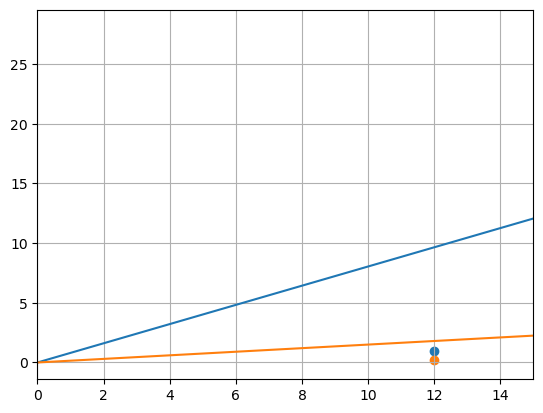

In [5]:
# using resolutions to decide scale bar length 

x = np.linspace(0, 35, 50)
y_pkpc = resolution_pkpc * x
y_as = resolution_as * x

plt.plot(x, y_pkpc)
plt.plot(x,y_as)

# --- EUCLID ---
# plt.scatter(3,2.5)
# plt.scatter(3,0.5)
# plt.xticks(np.arange(1,10,1))
# plt.yticks(np.arange(0,8,0.5))
# plt.xlim(0,5)
# plt.ylim(0,5)

# --- JWST F150W ---
plt.scatter(12,1)
plt.scatter(12,0.2)
plt.xlim(0,15)
# plt.ylim(0,3)
# plt.yticks(np.arange(0,2,0.1))

# --- JWST F444W ---
# plt.scatter(6,1)
# plt.scatter(6,0.2)
# plt.yticks(np.arange(0,2,0.1))

plt.grid()
plt.show()

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

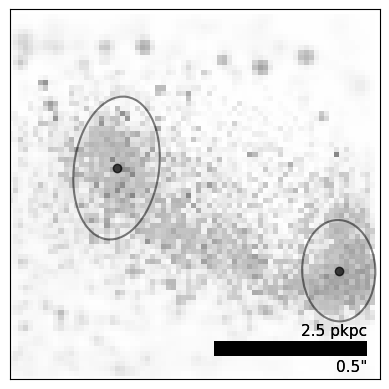

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

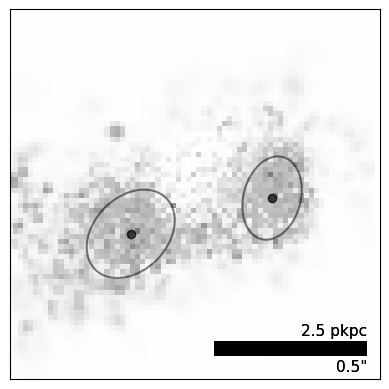

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

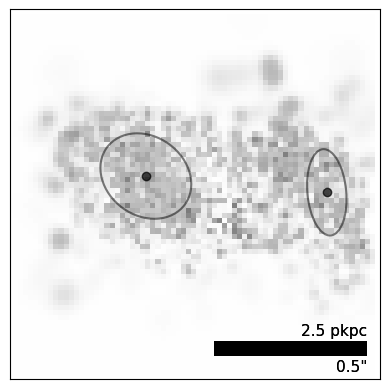

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

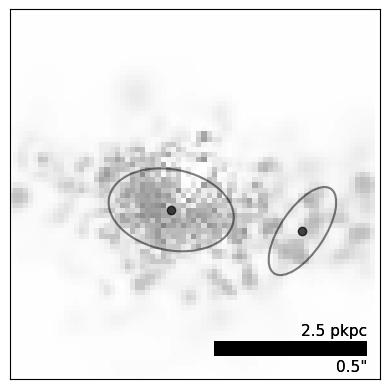

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

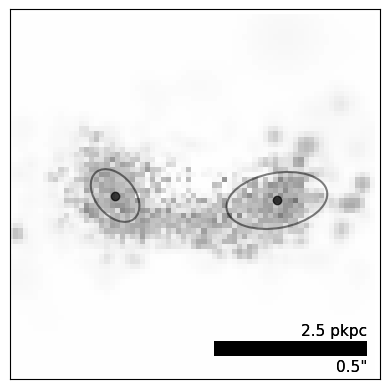

In [6]:
# -----------------------------
# ----- F150W WITHOUT PSF -----
# -----------------------------
redshift    = 7
pchi        = 30
noise_level = 0
filter      = 'f150w'
telescope   = 'jwst'

pair_indices = [
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
]

id_list = [29, 217, 285, 586, 641]

for id in id_list:
    img_nopsf, img = grab_image(id, telescope, filter, catalog=catalog, redshift=redshift)
    img = img.astype(img.dtype.newbyteorder('='))
    img_nopsf = img_nopsf.astype(img_nopsf.dtype.newbyteorder('='))
    print(f"img_nopsf dimensions: {img_nopsf.shape}, img dimensions: {img.shape}")

    # visualize
    fig, ax = plt.subplots()
    ax.imshow(img_nopsf, cmap='RdGy', origin='lower', norm=SymLogNorm(0.1, 1, vmin=-pchi, vmax=pchi))

    # --- DETECT OBJECTS FOR F150W NO PSF ---
    objects, seg_map = sep.extract(
        img_nopsf, 
        thresh=0.005, 
        minarea=50, 
        filter_kernel=None, 
        deblend_nthresh=32, 
        deblend_cont=1e-2, 
        clean_param=0.01, 
        segmentation_map=True
        )

    object_mask = seg_map.astype(float)
    object_mask[object_mask == 0] = np.nan
    # ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')

    objects = np.sort(objects, order='npix')[::-1]
    
    for obj in objects[:2]:
        x = obj['x']
        y = obj['y']
        a = obj['a']     # semi-major axis
        b = obj['b']     # semi-minor axis
        theta = obj['theta']   # in radians
        area = obj['npix']
        flux = obj['flux']
    
        print(f"ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area, obj['tnpix']}, Flux: {flux:.2f}")
        ax.scatter(obj['x'],obj['y'],c='black',alpha=0.7) # plotting centroids
        
        # Draw the ellipse  
        ellipse = patches.Ellipse(
            (x, y),        # center
            2*a, 2*b,      # full major/minor diameters
            angle=np.degrees(theta),
            edgecolor='black',
            facecolor='none',
            linewidth=1.5,
            alpha=0.5
    )
        ax.add_patch(ellipse)

        # --- JWST scale --- 
        rect = Rectangle(
            (40,4.5),
            width=30, height=3,
            facecolor='k'
        )
        ax.add_patch(rect)

        ax.text(64, 1.5, '0.5"', fontsize=11)
        ax.text(57, 8.5, '2.5 pkpc', fontsize=11)

        # --- EUCLID scale --- 
        # rect = Rectangle(
        #     (8,0.5),
        #     width=3, height=0.5,
        #     facecolor='k'
        # )
        # ax.add_patch(rect)

        # ax.text(8, 0, '0.5"', fontsize=11)
        # ax.text(8, 1.2, '2.5 pkpc', fontsize=11)


    plt.xlim(0,72.5)
    plt.ylim(0,72.5)
    plt.xticks([])
    plt.yticks([]) 

    plt.xticks([])
    plt.yticks([])
    plt.show()


1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

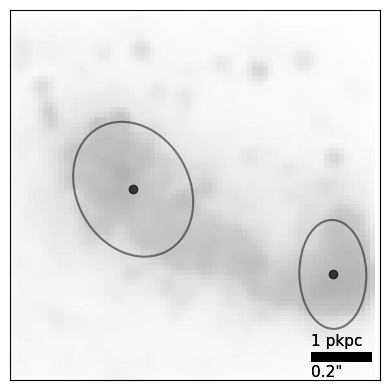

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

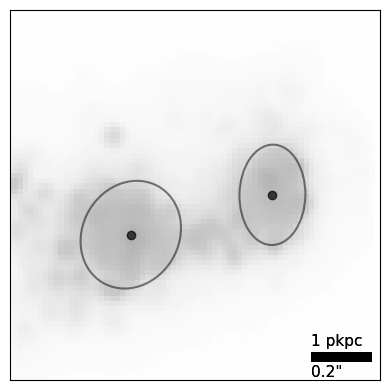

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

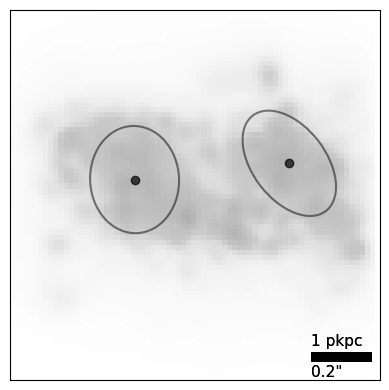

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

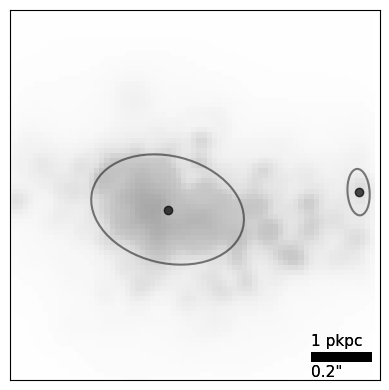

1 f150w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

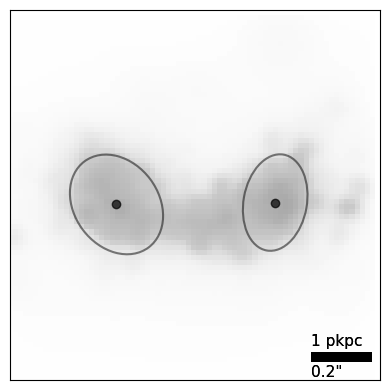

In [7]:
# --------------------------
# ----- F150W WITH PSF -----
# --------------------------
redshift    = 7
pchi        = 30
noise_level = 0
filter      = 'f150w'
telescope   = 'jwst'

pair_indices = [
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
]

# id_list = [217,76,50,378,636]

for id in id_list:
    img_nopsf, img = grab_image(id, telescope='jwst', filter=filter, catalog=catalog, redshift=redshift)
    img = img.astype(img.dtype.newbyteorder('='))
    img_nopsf = img_nopsf.astype(img_nopsf.dtype.newbyteorder('='))
    print(f"img_nopsf dimensions: {img_nopsf.shape}, img dimensions: {img.shape}")

    # visualize
    fig, ax = plt.subplots()
    ax.imshow(img, cmap='RdGy', origin='lower', norm=SymLogNorm(0.1, 1, vmin=-pchi, vmax=pchi))

    # --- DETECT OBJECTS FOR F150W WITH PSF ---
    objects, seg_map = sep.extract(
        img, 
        thresh=0.0005, 
        minarea=50, 
        filter_kernel=None, 
        deblend_nthresh=64, 
        deblend_cont=1e-3, 
        clean_param=0.01, 
        segmentation_map=True
        )
    object_mask = seg_map
    print(np.unique(object_mask))


    object_mask = seg_map.astype(float)
    object_mask[object_mask == 0] = np.nan
    # ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')

    objects = np.sort(objects, order='npix')[::-1]
    for obj in objects[:2]:

        x = obj['x']
        y = obj['y']
        a = obj['a']     # semi-major axis
        b = obj['b']     # semi-minor axis
        theta = obj['theta']   # in radians
        area = obj['npix']
        flux = obj['flux']
    
        print(f"ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area, obj['tnpix']}, Flux: {flux:.2f}")
        ax.scatter(obj['x'],obj['y'],c='black',alpha=0.7) # plotting centroids
        
        # Draw the ellipse  
        ellipse = patches.Ellipse(
            (x, y),        # center
            2*a, 2*b,      # full major/minor diameters
            angle=np.degrees(theta),
            edgecolor='black',
            facecolor='none',
            linewidth=1.5,
            alpha=0.5
    )
        ax.add_patch(ellipse)

        # --- JWST scale --- 
        rect = Rectangle(
            (59,3.5),
            width=12, height=2,
            facecolor='k'
        )
        ax.add_patch(rect)

        ax.text(59, 0.5, '0.2"', fontsize=11)
        ax.text(59, 6.5, '1 pkpc', fontsize=11)

        # --- EUCLID scale --- 
        # rect = Rectangle(
        #     (8,0.5),
        #     width=3, height=0.5,
        #     facecolor='k'
        # )
        # ax.add_patch(rect)

        # ax.text(8, 0, '0.5"', fontsize=11)
        # ax.text(8, 1.2, '2.5 pkpc', fontsize=11)

    plt.xlim(0,72.5)
    plt.ylim(0,72.5)
    plt.xticks([])
    plt.yticks([])

    plt.xticks([])
    plt.yticks([])
    plt.show()


1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

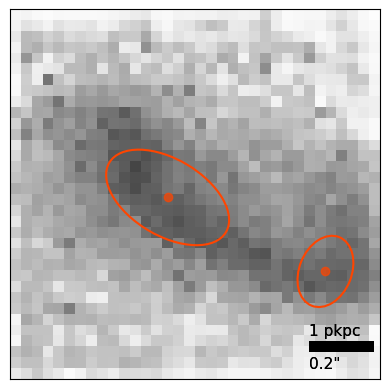

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

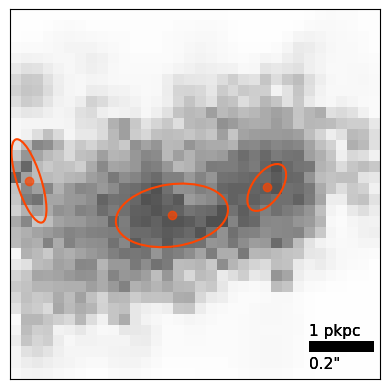

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

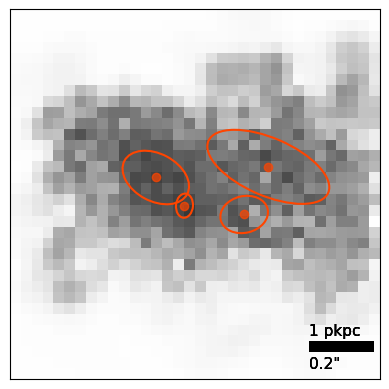

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

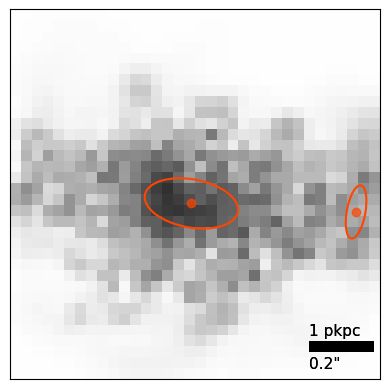

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

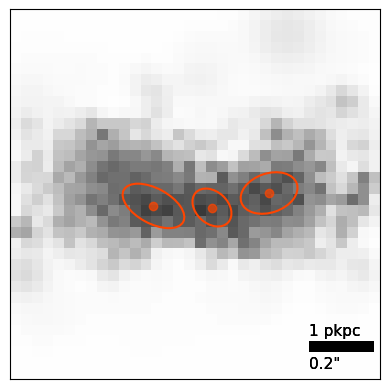

In [8]:
# -----------------------------
# ----- F444W WITHOUT PSF -----
# -----------------------------
# redshift    = 7
pchi        = 30
noise_level = 0
filter      = 'f444w'
telescope = 'jwst'

pair_indices = [
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
]

# id_list = [217,76,29,50,378,636,523]

for id in id_list:
    img_nopsf, img = grab_image(id, telescope, filter, catalog=catalog, redshift=redshift)
    img = img.astype(img.dtype.newbyteorder('='))
    img_nopsf = img_nopsf.astype(img_nopsf.dtype.newbyteorder('='))
    print(f"img_nopsf dimensions: {img_nopsf.shape}, img dimensions: {img.shape}")

    # visualize
    fig, ax = plt.subplots()
    ax.imshow(img_nopsf, cmap='RdGy', origin='lower', norm=SymLogNorm(0.1, 1, vmin=-pchi, vmax=pchi))


    # --- DETECT OBJECTS FOR F444W WITHOUT PSF --- 
    objects, seg_map = sep.extract(
        img_nopsf, 
        thresh=0.3,  
        minarea=20, 
        filter_kernel=None, 
        deblend_nthresh=64, 
        deblend_cont=1e-2, 
        clean_param=0.001, 
        segmentation_map=True
        )  

    object_mask = seg_map.astype(float)
    object_mask[object_mask == 0] = np.nan
    # ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')

    objects = np.sort(objects, order='npix')[::-1]
    for obj in objects:
        x = obj['x']
        y = obj['y']
        a = obj['a']     # semi-major axis
        b = obj['b']     # semi-minor axis
        theta = obj['theta']   # in radians
        area = obj['npix']
        flux = obj['flux']

        print(f"ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area, obj['tnpix']}, Flux: {flux:.2f}")
        # plotting centroids
        ax.scatter(
            obj['x'],obj['y'],
            c='orangered',
            alpha=0.7
            ) 
        
        # Draw the ellipse  
        ellipse = patches.Ellipse(
            (x, y),        # center
            2*a, 2*b,      # full major/minor diameters
            angle=np.degrees(theta),
            edgecolor='orangered',
            facecolor='none',
            linewidth=1.5
        )
        ax.add_patch(ellipse)

        # --- JWST scale --- 
        rect = Rectangle(
            (27,2),
            width=6, height=1,
            facecolor='k'
        )
        ax.add_patch(rect)

        ax.text(27, 0.5, '0.2"', fontsize=11)
        ax.text(27, 3.5, '1 pkpc', fontsize=11)

        # --- EUCLID scale --- 
        # rect = Rectangle(
        #     (8,0.5),
        #     width=3, height=0.5,
        #     facecolor='k'
        # )
        # ax.add_patch(rect)

        # ax.text(8, 0, '0.5"', fontsize=11)
        # ax.text(8, 1.2, '2.5 pkpc', fontsize=11)

    # plt.xlim(-0.5,11.5)
    # plt.ylim(-0.5,11.5)
    plt.xticks([])
    plt.yticks([]) 
    plt.show()

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

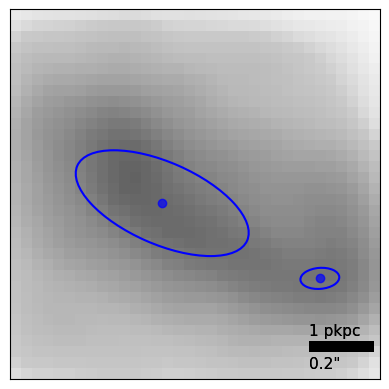

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

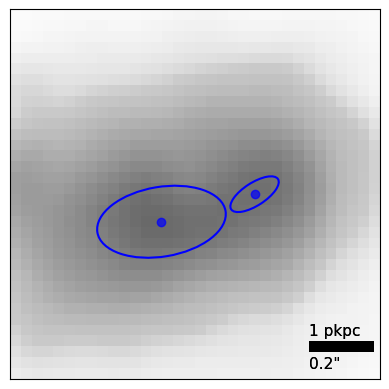

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

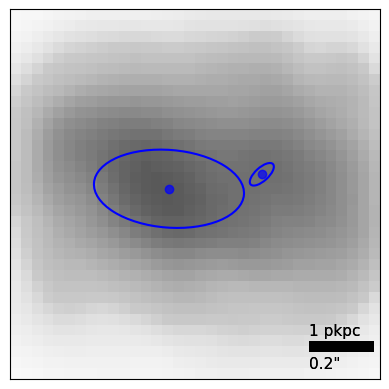

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

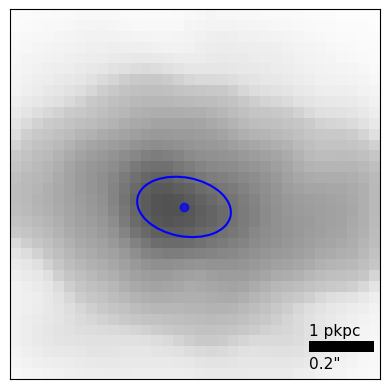

1 f444w
['/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f277w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f150w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file1_f115w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file3_f444w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file2_f090w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f356w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f200w_v1_sim-nopsf.fits', '/Users/lhenson/Documents/Research_UCR/BlueTides/jwst_all_nopsf/hlsp_bluetides_jwst_nircam_z7-file4_f444w_v1_

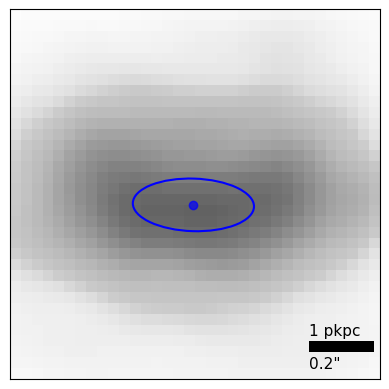

In [9]:
# --------------------------
# ----- F444W WITH PSF -----
# --------------------------
redshift    = 7
pchi        = 30
noise_level = 0
filter      = 'f444w'
telescope = 'jwst'

pair_indices = [
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
]

# id_list = [217,76,29,50,378,636,523]

for id in id_list:
    img_nopsf, img = grab_image(id, telescope, filter, catalog=catalog, redshift=redshift)
    img = img.astype(img.dtype.newbyteorder('='))
    img_nopsf = img_nopsf.astype(img_nopsf.dtype.newbyteorder('='))
    print(f"img_nopsf dimensions: {img_nopsf.shape}, img dimensions: {img.shape}")

    # visualize
    fig, ax = plt.subplots()
    ax.imshow(img, cmap='RdGy', origin='lower', norm=SymLogNorm(0.1, 1, vmin=-pchi, vmax=pchi))


    # --- DETECT OBJECTS FOR F444W WITH PSF --- 
    objects, seg_map = sep.extract(
        img, 
        thresh= 0.5,  
        minarea=50, 
        filter_kernel=None, 
        deblend_nthresh=128, 
        deblend_cont=1e-8, 
        clean_param=0.001, 
        segmentation_map=True
        )

    object_mask = seg_map.astype(float)
    object_mask[object_mask == 0] = np.nan
    # ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')

    objects = np.sort(objects, order='npix')[::-1]
    for obj in objects:
        x = obj['x']
        y = obj['y']
        a = obj['a']     # semi-major axis
        b = obj['b']     # semi-minor axis
        theta = obj['theta']   # in radians
        area = obj['npix']
        flux = obj['flux']

        print(f"ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area, obj['tnpix']}, Flux: {flux:.2f}")
        ax.scatter(obj['x'],obj['y'],c='blue',alpha=0.7) # plotting centroids

        # Draw the ellipse  
        ellipse = patches.Ellipse(
            (x, y),        # center
            2*a, 2*b,      # full major/minor diameters
            angle=np.degrees(theta),
            edgecolor='blue',
            facecolor='none',
            linewidth=1.5
    )
        ax.add_patch(ellipse)

        # --- JWST scale --- 
        rect = Rectangle(
            (27,2),
            width=6, height=1,
            facecolor='k'
        )
        ax.add_patch(rect)

        ax.text(27, 0.5, '0.2"', fontsize=11)
        ax.text(27, 3.5, '1 pkpc', fontsize=11)

        # --- EUCLID scale --- 
        # rect = Rectangle(
        #     (8,0.5),
        #     width=3, height=0.5,
        #     facecolor='k'
        # )
        # ax.add_patch(rect)

        # ax.text(8, 0, '0.5"', fontsize=11)
        # ax.text(8, 1.2, '2.5 pkpc', fontsize=11)

    # plt.xlim(-0.5,11.5)
    # plt.ylim(-0.5,11.5)
    plt.xticks([])
    plt.yticks([]) 
    plt.show()

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

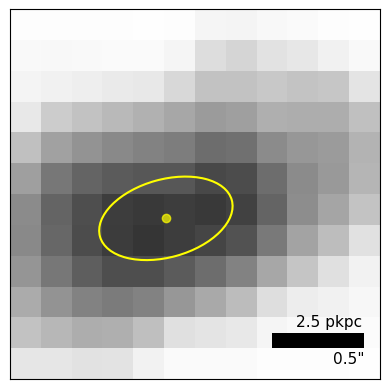

1 h
['/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file1_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file2_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_h_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_j_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_nisp_z7-file3_y_v1_sim-nopsf.fits', '/Volumes/SeagateBack/bluetides/euclid_nopsf/hlsp_bluetides_euclid_n

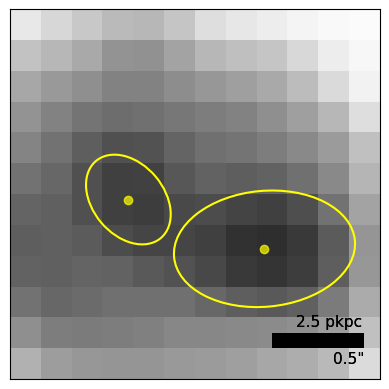

In [10]:
# ---------------------------
# ----- EUCLID with PSF -----
# ---------------------------
redshift    = 7
pchi        = 30
noise_level = 0
filter      = 'h'
telescope = 'euclid'

pair_indices = [
    2, 8, 13, 17, 19, 25, 27, 33, 37, 38, 41, 57, 62, 64, 72, 76, 79, 87, 88, 90,
    93, 94, 95, 97, 98, 99, 105, 107, 109, 112, 117, 128, 136, 147, 167, 171, 184,
    191, 199, 201, 204, 209, 217, 228, 233, 285, 311, 326, 330, 332, 344, 357, 364,
    385, 388, 396, 402, 405, 407, 433, 456, 469, 472, 494, 504, 511, 523, 530, 556,
    559, 568, 616, 617, 625, 640, 641, 650, 657, 664, 669, 678, 681, 683, 727, 729,
    745, 749, 760, 773, 794, 800, 802, 814, 821, 830, 845, 850, 852, 870, 879, 903,
    915, 919, 954, 987, 997
]

id_list = [217, 29]

for id in id_list:
    img_nopsf, img = grab_image(id, telescope, filter, catalog=catalog, redshift=redshift)
    img = img.astype(img.dtype.newbyteorder('='))
    img_nopsf = img_nopsf.astype(img_nopsf.dtype.newbyteorder('='))
    print(f"img_nopsf dimensions: {img_nopsf.shape}, img dimensions: {img.shape}")

    # visualize
    fig, ax = plt.subplots()
    ax.imshow(img, cmap='RdGy', origin='lower', norm=SymLogNorm(0.1, 1, vmin=-pchi, vmax=pchi))


    # --- DETECT OBJECTS FOR F444W WITH PSF --- 
    objects, seg_map = sep.extract(
        img, 
        thresh=0.0008, 
        minarea=20, 
        filter_kernel=None, 
        deblend_nthresh=32, 
        deblend_cont=1e-3, 
        clean_param=0.01, 
        segmentation_map=True
        )   

    object_mask = seg_map.astype(float)
    object_mask[object_mask == 0] = np.nan
    # ax.imshow(object_mask, cmap='spring', alpha=0.3, origin='lower')

    objects = np.sort(objects, order='npix')[::-1]
    for obj in objects:
        x = obj['x']
        y = obj['y']
        a = obj['a']     # semi-major axis
        b = obj['b']     # semi-minor axis
        theta = obj['theta']   # in radians
        area = obj['npix']
        flux = obj['flux']

        print(f"ID:{id}, Object at (x, y): ({x:.2f}, {y:.2f}), Area: {area, obj['tnpix']}, Flux: {flux:.2f}")
        ax.scatter(obj['x'],obj['y'],c='yellow',alpha=0.7) # plotting centroids

        # Draw the ellipse  
        ellipse = patches.Ellipse(
            (x, y),        # center
            2*a, 2*b,      # full major/minor diameters
            angle=np.degrees(theta),
            edgecolor='yellow',
            facecolor='none',
            linewidth=1.5
    )
        ax.add_patch(ellipse)

        # --- JWST scale --- 
        rect = Rectangle(
            (8,0.5),
            width=3, height=0.5,
            facecolor='k'
        )
        ax.add_patch(rect)

        ax.text(10, 0, '0.5"', fontsize=11)
        ax.text(8.8, 1.2, '2.5 pkpc', fontsize=11)

        # --- EUCLID scale --- 
        # rect = Rectangle(
        #     (8,0.5),
        #     width=3, height=0.5,
        #     facecolor='k'
        # )
        # ax.add_patch(rect)

        # ax.text(8, 0, '0.5"', fontsize=11)
        # ax.text(8, 1.2, '2.5 pkpc', fontsize=11)

    plt.xlim(-0.5,11.5)
    plt.ylim(-0.5,11.5)
    plt.xticks([])
    plt.yticks([]) 
    plt.show()